# Section 3 — Interpretable Machine Learning

Open the black boxes from Section 2. Global surrogate models, permutation feature importance, partial dependence plots, individual conditional expectation, LIME, SHAP, and counterfactual explanations — applied to the same two real-world insurance datasets, with one consistent regression model and one consistent classification model carrying the narrative end-to-end.

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger (8–9 June 2026, Munich).

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/simonhatzesberger/ml-genai-actuarial-practice/blob/main/notebooks/03_interpretable_ml/03_interpretable_ml.ipynb)

Repository: [simonhatzesberger/ml-genai-actuarial-practice](https://github.com/simonhatzesberger/ml-genai-actuarial-practice) — Code under the [MIT License](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).

Section 2's modern ensembles and the feed-forward neural network closed the gap on calibration and log-loss — but they did so behind a wall of trees and weights that no underwriter can read directly. Section 3 opens that wall with two questions:

1. **What are the main drivers of the model's prediction?** — a *global* question, answered across the full portfolio.
2. **What influence does a specific feature have on the prediction?** — a *local* question, answered one policyholder at a time.

The methods we will apply fall into two families:

- **Intrinsic** explanations — the model itself is transparent (e.g., linear/logistic coefficients, a small tree). Free, but limited to model families with low capacity.
- **Post-hoc** explanations — a separate procedure applied *after* the model is trained. Splits further into **global** methods (e.g., surrogate models, permutation feature importance, partial dependence plots) and **local** methods (e.g., ICE, LIME, SHAP, counterfactuals).

> **Why interpretability is not optional.** The EU AI Act, Article 13(1), requires that *"high-risk AI systems shall be designed and developed in such a way to ensure that their operation is sufficiently transparent to enable deployers to interpret the system's output and use it appropriately."* The EIOPA AI Governance Principles (2021) restate the same requirement for the European insurance sector: *"Explainability is part of the concept of transparency and concerns the ability to explain the output of the AI system to a particular audience, in particular the weight / influence and causal relationship of a specific variable (or group of variables) in the final output."* In short — every regulator who looks at your pricing pipeline expects a defensible answer to question 1, and every customer who appeals a quote expects a defensible answer to question 2.

## Contents

- [Learning objectives](#learning-objectives)
- [Setup](#setup)
- [1. The two black boxes we will open](#1-the-two-black-boxes-we-will-open)
- [2. Intrinsic interpretability — the white-box baselines](#2-intrinsic-interpretability)
- [3. Global post-hoc methods](#3-global-post-hoc-methods)
  - [3.1 Global surrogate models](#31-global-surrogate-models)
  - [3.2 Permutation feature importance](#32-permutation-feature-importance)
  - [3.3 Partial dependence plots (PDP)](#33-partial-dependence-plots)
- [4. Local post-hoc methods](#4-local-post-hoc-methods)
  - [4.1 Individual conditional expectation (ICE)](#41-individual-conditional-expectation)
  - [4.2 LIME](#42-lime)
  - [4.3 SHAP](#43-shap)
  - [4.4 Counterfactual explanations](#44-counterfactual-explanations)
- [5. Putting it together — when to use which method](#5-putting-it-together)
- [Exercises](#exercises)
- [Summary](#summary)
- [Next steps](#next-steps)
- [References](#references)

## Learning objectives

By the end of this notebook you will be able to:

- distinguish **intrinsically interpretable** models from **post-hoc** explanation methods, and place every method covered on the (global ↔ local) × (intrinsic ↔ post-hoc) grid;
- read the coefficients of a linear or logistic regression as a built-in *global* explanation, and understand when intrinsic interpretation is no longer enough;
- apply the **global post-hoc** toolkit — surrogate models, permutation feature importance, partial dependence plots — to a black-box regression and a black-box classification model;
- apply the **local post-hoc** toolkit — ICE, LIME, SHAP, counterfactuals — to explain individual predictions, and recognise where each method's assumptions break;
- relate the methods to the **EU AI Act** and **EIOPA 2021** explainability requirements that govern actuarial AI in production.

## Setup

The cell below detects whether you are on Google Colab. On Colab it installs the section's pinned dependencies and downloads the two datasets used throughout the notebook — the same `data_medical_cost.csv` and `data_car_insurance.csv` you already met in Sections 1 and 2.

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q -r https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/requirements.txt
    !mkdir -p data
    !wget -q -O data/data_medical_cost.csv  https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/data/data_medical_cost.csv
    !wget -q -O data/data_car_insurance.csv https://raw.githubusercontent.com/simonhatzesberger/ml-genai-actuarial-practice/main/notebooks/03_interpretable_ml/data/data_car_insurance.csv

SEED = 42

print(f"Setup complete. Environment: {'Colab' if IN_COLAB else 'local'}.")

Setup complete. Environment: local.


The same palette and seaborn theme as Sections 1 and 2 — every figure in the notebook inherits these colours.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PRIMARY      = "#1F3A6E"
ACCENT_RED   = "#C0504D"
ACCENT_GREEN = "#4E7C59"
GRAY_TEXT    = "#404040"

sns.set_theme(
    style="whitegrid",
    palette=[PRIMARY, ACCENT_RED, ACCENT_GREEN, "#7A8DA8", "#9C7A7A"],
    rc={
        "axes.edgecolor":   GRAY_TEXT,
        "axes.labelcolor":  GRAY_TEXT,
        "xtick.color":      GRAY_TEXT,
        "ytick.color":      GRAY_TEXT,
        "axes.titlecolor":  PRIMARY,
        "axes.titleweight": "bold",
        "grid.color":       "#E5E5E5",
        "figure.facecolor": "white",
        "axes.facecolor":   "white",
    },
)

np.random.seed(SEED)

## 1. The two black boxes we will open

Section 2 trained Random Forests, CatBoost, and feed-forward neural networks on the two insurance datasets, and CatBoost came out as a very strong off-the-shelf method on each. The whole rest of this notebook applies model-agnostic explainability to **one CatBoost regressor on Medical Costs** and **one CatBoost classifier on Car Insurance** — both trained here, in two short cells, with hyperparameters lifted from Section 2.

Why CatBoost and not, say, the Random Forest? Three reasons: (i) it is *the* off-the-shelf workhorse on tabular data, so explainability methods are most useful when applied to it; (ii) it handles categorical features natively, which keeps the data-flow clean; (iii) `shap.TreeExplainer` runs in milliseconds on a CatBoost model, where `KernelExplainer` would take minutes.

### The regression black box — CatBoost on medical charges

In [3]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load the Medical Costs data; split features (X) from the target (annual charges).
df_reg = pd.read_csv("data/data_medical_cost.csv")
target_reg = "charges"
X_reg = df_reg.drop(columns=[target_reg])
y_reg = df_reg[target_reg]

cat_cols_r = ["sex", "smoker", "region"]
num_cols_r = ["age", "bmi", "children"]

# Hold out 20% as a test set we never train on.
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=SEED
)

# Train the CatBoost regressor — the "black box" the rest of the notebook will explain.
cb_reg = CatBoostRegressor(
    iterations=500,
    learning_rate=0.02,
    depth=6,
    cat_features=cat_cols_r,
    random_seed=SEED,
    verbose=False,
)
cb_reg.fit(X_train_r, y_train_r)

# Evaluate on the held-out test set.
y_pred_r = cb_reg.predict(X_test_r)
pd.DataFrame({
    "RMSE": [np.sqrt(mean_squared_error(y_test_r, y_pred_r))],
    "MAE":  [mean_absolute_error(y_test_r, y_pred_r)],
    "R²":   [r2_score(y_test_r, y_pred_r)],
}, index=["CatBoost regressor"]).style.format({"RMSE": "{:,.0f}", "MAE": "{:,.0f}", "R²": "{:.3f}"})

,RMSE,MAE,R²
CatBoost regressor,"4,288","2,400",0.882


### The classification black box — CatBoost on car-insurance claims

In [4]:
from catboost import CatBoostClassifier
from sklearn.metrics import log_loss, roc_auc_score, f1_score, accuracy_score

# Load Car Insurance; drop the ID column; split features from the binary claim target.
df_cls = pd.read_csv("data/data_car_insurance.csv").drop(columns=["ID"])
target_cls = "OUTCOME"
X_cls = df_cls.drop(columns=[target_cls])
y_cls = df_cls[target_cls].astype(int)

# Split columns into numeric vs categorical (POSTAL_CODE is an ID-like code → categorical).
num_cols_c = [c for c in X_cls.columns
              if X_cls[c].dtype != "object" and c != "POSTAL_CODE"]
cat_cols_c = [c for c in X_cls.columns if c not in num_cols_c]

# CatBoost prefers no missing values in numeric columns — median-impute up front so
# every downstream explainer sees a clean frame.
X_cls[num_cols_c] = X_cls[num_cols_c].fillna(X_cls[num_cols_c].median())
X_cls[cat_cols_c] = X_cls[cat_cols_c].astype(str)

# Stratified split keeps the claim rate identical in train and test.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.20, random_state=SEED, stratify=y_cls
)

# Train the CatBoost classifier — the second black box, for the claim-probability task.
cb_cls = CatBoostClassifier(
    iterations=500,
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=3.0,
    cat_features=cat_cols_c,
    random_seed=SEED,
    verbose=False,
)
cb_cls.fit(X_train_c, y_train_c)

# Evaluate on the held-out test set.
p_cb = cb_cls.predict_proba(X_test_c)[:, 1]
yhat_cb = (p_cb >= 0.5).astype(int)
pd.DataFrame({
    "log_loss": [log_loss(y_test_c, p_cb)],
    "AUC":      [roc_auc_score(y_test_c, p_cb)],
    "F1":       [f1_score(y_test_c, yhat_cb)],
    "accuracy": [accuracy_score(y_test_c, yhat_cb)],
}, index=["CatBoost classifier"]).style.format({"log_loss": "{:.4f}", "AUC": "{:.3f}", "F1": "{:.3f}", "accuracy": "{:.3f}"})

,log_loss,AUC,F1,accuracy
CatBoost classifier,0.3379,0.916,0.756,0.844


**Reading the metrics.** Both models land where Section 2 said they would: the regressor explains roughly 88% of the variance in medical charges; the classifier delivers AUC ≈ 0.92 on the car-insurance claims. From here on, the *numbers* are settled — we will spend the rest of the notebook explaining **why** the models make the predictions they make.

## 2. Intrinsic interpretability — the white-box baselines

Intrinsic interpretability is the one method family that needs *no extra machinery at all*: pick a model whose internals you can read off directly. The two classical examples we already trained in Section 1 sit here — **linear regression** for Medical Costs, **logistic regression** for Car Insurance. We re-fit them now on the *standardised* features so the coefficients are directly comparable in magnitude.

> **A note on tree visualisation.** A single shallow decision tree (Section 1) is also intrinsically interpretable — every split is a rule a human can read. We will use that property again in §3.1 when we fit a tree as a *surrogate* for the CatBoost models. The principle is the same; only the data we fit the tree to changes.

### Standardised linear-regression coefficients on Medical Costs

In [5]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Standardise numerics; one-hot encode categoricals (drop one level to avoid collinearity).
# Standardising puts every coefficient on the same scale, so their sizes are comparable.
preprocess_reg = ColumnTransformer([
    ("num", StandardScaler(),                       num_cols_r),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols_r),
])
preprocess_reg.fit(X_train_r)
feature_names_r = (
    num_cols_r
    + list(preprocess_reg.named_transformers_["cat"].get_feature_names_out(cat_cols_r))
)

# Fit ordinary least squares on the standardised design matrix; sort by |coefficient|.
lin_reg = LinearRegression().fit(preprocess_reg.transform(X_train_r), y_train_r)
coef_r = pd.Series(lin_reg.coef_, index=feature_names_r, name="coefficient (USD)").sort_values(key=np.abs, ascending=False)
coef_r.to_frame().style.format({"coefficient (USD)": "{:,.0f}"}).background_gradient(cmap="RdBu_r", vmin=-coef_r.abs().max(), vmax=coef_r.abs().max())

,coefficient (USD)
smoker_yes,"23,651"
age,"3,615"
bmi,"2,036"
region_southwest,-810
region_southeast,-658
children,517
region_northwest,-371
sex_male,-19


**Reading the coefficients.** `smoker_yes` is by far the dominant driver: at roughly **+23,650 USD** it outweighs the *summed* magnitude of every other coefficient (about **8,000 USD**) by a factor of three. `age` (+3,600 USD) and `bmi` (+2,000 USD) come next — several times smaller — followed by the region indicators and `children`, all of a few hundred dollars; `sex` is negligible. **This is the intrinsic explanation in its purest form** — the model's internals *are* the explanation. The catch: this linear model reaches only **R² ≈ 0.78** on the test set, against the CatBoost regressor's **R² ≈ 0.88** — because the *real* relationship is non-linear (an interaction between `smoker` and `bmi`, which we will see clearly in §3.3 and §4.3).

### Standardised logistic-regression coefficients on Car Insurance

In [6]:
# Standardise numerics, one-hot encode categoricals (drop one level to avoid collinearity).
preprocess_cls = ColumnTransformer([
    ("num", StandardScaler(),                                       num_cols_c),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),   cat_cols_c),
])
preprocess_cls.fit(X_train_c)
feature_names_c = (
    num_cols_c
    + list(preprocess_cls.named_transformers_["cat"].get_feature_names_out(cat_cols_c))
)

# Fit logistic regression on the standardised design matrix; show the 15 largest coefficients.
log_reg = LogisticRegression(max_iter=1000, random_state=SEED).fit(
    preprocess_cls.transform(X_train_c), y_train_c
)
coef_c = pd.Series(log_reg.coef_.ravel(), index=feature_names_c, name="log-odds coefficient").sort_values(key=np.abs, ascending=False).head(15)
coef_c.to_frame().style.format({"log-odds coefficient": "{:+.2f}"}).background_gradient(cmap="RdBu_r", vmin=-coef_c.abs().max(), vmax=coef_c.abs().max())

,log-odds coefficient
POSTAL_CODE_21217,+6.92
DRIVING_EXPERIENCE_30y+,-4.06
DRIVING_EXPERIENCE_20-29y,-3.84
VEHICLE_YEAR_before 2015,+1.90
DRIVING_EXPERIENCE_10-19y,-1.86
POSTAL_CODE_92101,+1.26
POSTAL_CODE_32765,+1.19
GENDER_male,+1.05
VEHICLE_OWNERSHIP,-0.85
ANNUAL_MILEAGE,+0.30


**Reading the coefficients.** The table is sorted by absolute coefficient size. A single postal-code indicator (`POSTAL_CODE_21217`, +6.9) tops the list, followed by the `DRIVING_EXPERIENCE` bands — whose large *negative* coefficients say that more years behind the wheel sharply lower the claim odds. `VEHICLE_YEAR`, `GENDER`, and `VEHICLE_OWNERSHIP` come next; `INCOME` and `EDUCATION` do not even reach the top 15.

What is "one unit" of a coefficient? Because the **numeric** features were standardised, their coefficient is the effect of a **one-standard-deviation** increase — e.g. `ANNUAL_MILEAGE` at +0.30 means an odds ratio of `exp(0.30) ≈ 1.35` per standard deviation. For the **one-hot indicators** (postal code, driving-experience band, …) a "unit" is simply a 0→1 switch, so `exp(coef)` is the odds ratio for belonging to that category versus the dropped reference category. **What intrinsic interpretation cannot do:** describe non-linear effects, interactions between features, or anything CatBoost extracted that a linear model would miss. That gap motivates the rest of the notebook — *post-hoc* methods that work on any model, including the CatBoost models we just trained.

## 3. Global post-hoc methods

A *global* explanation answers question 1 from the introduction — what does the model do *on average*, across the whole portfolio. Three methods, in increasing detail:

1. **Surrogate models** — fit a simple, transparent model to the black box's *predictions* and read its internals. Cheap; gives a portrait of the black box as a whole.
2. **Permutation feature importance** — measure how much the model's predictive performance drops when we shuffle one feature. Tells you *which* features matter, not *how*.
3. **Partial dependence plots** — for each feature, average the model's prediction over the rest of the portfolio while sliding that feature across its range. Shows the *shape* of the dependence.

### 3.1 Global surrogate models

The recipe is almost embarrassingly simple:

1. Run the black box on the training set → get its predictions.
2. Fit a simple interpretable model (e.g., a shallow tree or a linear/logistic model) to the *black-box predictions* as the target.
3. Read the simple model's internals as an approximation of the black box.

The surrogate's R² against the black box (called *fidelity*) tells you how trustworthy this approximation is. Two surrogate families are common — a **shallow tree** captures interactions but produces piecewise-constant approximations; a **linear/logistic** surrogate gives signed effects but ignores interactions. Below we fit *both* on each dataset so the trade-off is concrete.

#### Decision-tree surrogate — regression

Tree-surrogate fidelity (R² against CatBoost) on Medical Costs: 0.978


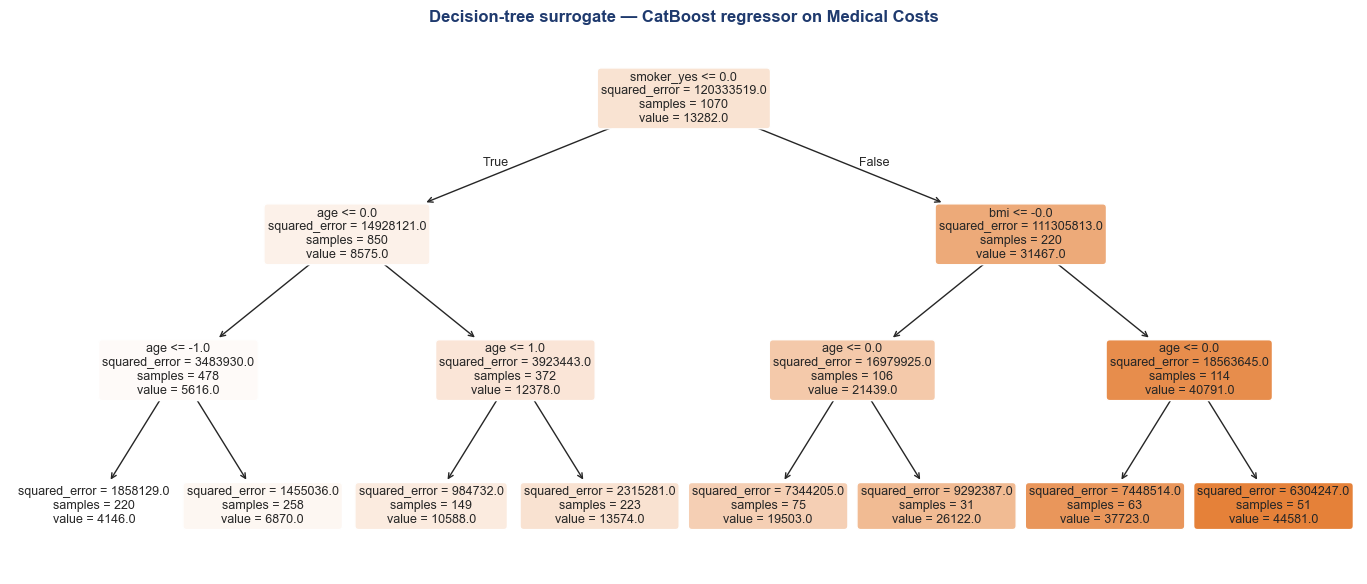

In [7]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

# 1. Get black-box predictions on the training set.
y_train_r_blackbox = cb_reg.predict(X_train_r)
y_test_r_blackbox  = cb_reg.predict(X_test_r)

# 2. Fit a shallow tree to those predictions. Use the same one-hot encoded features
#    so the surrogate is human-readable.
X_train_r_enc = preprocess_reg.transform(X_train_r)
X_test_r_enc  = preprocess_reg.transform(X_test_r)

surrogate_tree_r = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(
    X_train_r_enc, y_train_r_blackbox
)

fidelity_tree_r = r2_score(y_test_r_blackbox, surrogate_tree_r.predict(X_test_r_enc))
print(f"Tree-surrogate fidelity (R² against CatBoost) on Medical Costs: {fidelity_tree_r:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(surrogate_tree_r, feature_names=feature_names_r, filled=True,
          rounded=True, fontsize=9, precision=0, ax=ax)
ax.set_title("Decision-tree surrogate — CatBoost regressor on Medical Costs")
fig.tight_layout()
plt.show()

**Reading the surrogate tree.** The first split is on `smoker_yes` — exactly the dominant linear-regression coefficient from §2. Below it the tree branches differently on each side: the smoker branch splits on `bmi`, the non-smoker branch on `age` — the surrogate has rediscovered the smoker × BMI interaction (BMI only bites once you are a smoker). The fidelity (**R² ≈ 0.97** against the CatBoost predictions) tells us this depth-3 tree reproduces the black box almost exactly — an unusually faithful, defensible summary you can hand to a non-technical stakeholder.

#### Linear surrogate — regression

In [8]:
# A linear-regression surrogate on the same target gives signed coefficients —
# an alternative summary that complements the tree's splits.
surrogate_lin_r = LinearRegression().fit(X_train_r_enc, y_train_r_blackbox)
fidelity_lin_r = r2_score(y_test_r_blackbox, surrogate_lin_r.predict(X_test_r_enc))
print(f"Linear-surrogate fidelity (R² against CatBoost) on Medical Costs: {fidelity_lin_r:.3f}")

pd.DataFrame({
    "linear surrogate (USD per std)": surrogate_lin_r.coef_,
    "linear baseline (§2)":           lin_reg.coef_,
}, index=feature_names_r).sort_values("linear surrogate (USD per std)", key=np.abs, ascending=False).style.format("{:,.0f}")

Linear-surrogate fidelity (R² against CatBoost) on Medical Costs: 0.875


,linear surrogate (USD per std),linear baseline (§2)
smoker_yes,"23,342","23,651"
age,"3,583","3,615"
bmi,"1,959","2,036"
children,410,517
region_southwest,390,-810
region_southeast,311,-658
sex_male,133,-19
region_northwest,54,-371


**Reading the linear surrogate.** The signs and magnitudes of the surrogate's coefficients are very close to the linear regression we fitted directly on the data in §2 — which is the expected outcome when the black box itself is roughly linear in its effects. **The surrogate family is a choice** — a tree captures the smoker × BMI interaction, a linear surrogate gives signed effects you can quote in a regulatory report. In practice you fit both and look at fidelity to decide which you trust more.

#### Decision-tree surrogate — classification

Tree-surrogate fidelity (R² against CatBoost probabilities) on Car Insurance: 0.689


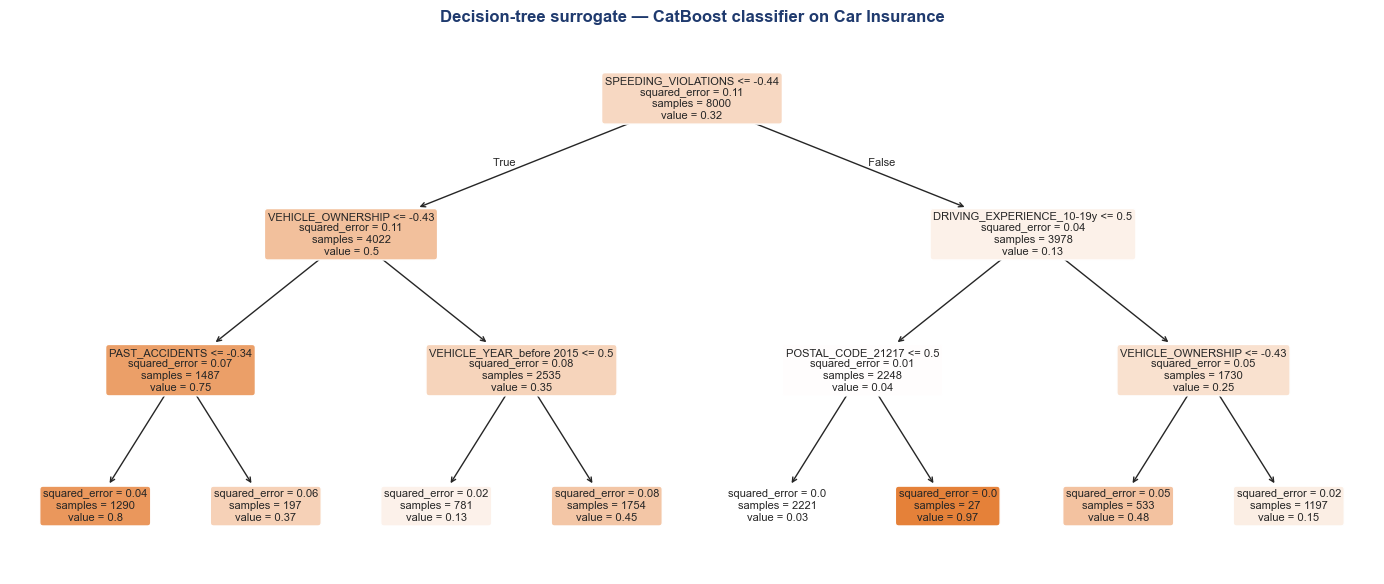

In [9]:
# Same recipe on the classification model — surrogate the *probabilities*.
p_train_c_blackbox = cb_cls.predict_proba(X_train_c)[:, 1]
p_test_c_blackbox  = cb_cls.predict_proba(X_test_c)[:, 1]

X_train_c_enc = preprocess_cls.transform(X_train_c)
X_test_c_enc  = preprocess_cls.transform(X_test_c)

surrogate_tree_c = DecisionTreeRegressor(max_depth=3, random_state=SEED).fit(
    X_train_c_enc, p_train_c_blackbox
)
fidelity_tree_c = r2_score(p_test_c_blackbox, surrogate_tree_c.predict(X_test_c_enc))
print(f"Tree-surrogate fidelity (R² against CatBoost probabilities) on Car Insurance: {fidelity_tree_c:.3f}")

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(surrogate_tree_c, feature_names=feature_names_c, filled=True,
          rounded=True, fontsize=8, precision=2, ax=ax)
ax.set_title("Decision-tree surrogate — CatBoost classifier on Car Insurance")
fig.tight_layout()
plt.show()

**Reading the surrogate tree.** The root split is on `SPEEDING_VIOLATIONS`, with `VEHICLE_OWNERSHIP`, the `DRIVING_EXPERIENCE` bands, and a `POSTAL_CODE` indicator just below — broadly the high-importance features the permutation test will confirm in §3.2. Each leaf is a portfolio segment whose claim probability you can read off directly, ranging from ≈ 0.03 to ≈ 0.98 (the high-risk `POSTAL_CODE_21217` leaf reaches 0.98). Note the lower fidelity here (**R² ≈ 0.67** vs ≈ 0.97 for the regression): a probability surface is harder for a depth-3 tree to capture than a smooth regression, so treat this tree as a faithful *sketch*, not a pixel-perfect copy.

#### Logistic surrogate — classification

In [10]:
surrogate_log_c = LogisticRegression(max_iter=1000, random_state=SEED).fit(
    X_train_c_enc, (p_train_c_blackbox >= 0.5).astype(int)
)
fidelity_log_c = roc_auc_score(
    (p_test_c_blackbox >= 0.5).astype(int),
    surrogate_log_c.predict_proba(X_test_c_enc)[:, 1],
)
print(f"Logistic-surrogate fidelity (AUC against CatBoost class labels) on Car Insurance: {fidelity_log_c:.3f}")

pd.Series(
    surrogate_log_c.coef_.ravel(), index=feature_names_c, name="log-odds (surrogate)"
).sort_values(key=np.abs, ascending=False).head(15).to_frame().style.format("{:+.2f}")

Logistic-surrogate fidelity (AUC against CatBoost class labels) on Car Insurance: 0.997


,log-odds (surrogate)
POSTAL_CODE_21217,+13.37
DRIVING_EXPERIENCE_20-29y,-8.83
DRIVING_EXPERIENCE_30y+,-6.58
VEHICLE_YEAR_before 2015,+5.68
DRIVING_EXPERIENCE_10-19y,-5.68
GENDER_male,+3.24
POSTAL_CODE_32765,+2.98
POSTAL_CODE_92101,+2.76
VEHICLE_OWNERSHIP,-2.34
AGE_40-64,-1.10


**Reading the logistic surrogate.** Compared with the *direct* logistic regression in §2, the surrogate's coefficients are scaled differently (it learned the black-box's *labels*, not the true outcome), but the *ranking* of important features tells the same story. **Use the tree surrogate to explain the model's segmentation, and the logistic surrogate to quote signed effects** — they complement, not compete.

### 3.2 Permutation feature importance

If we randomly shuffle the values of one feature in the test set, how much does the model's performance drop? A feature the model relies on heavily produces a large drop; an irrelevant feature produces essentially none. The procedure is **model-agnostic** (you only need `.predict`) and **respects the actual model**, not a surrogate.

We use scikit-learn's `permutation_importance`, scoring with `neg_root_mean_squared_error` for the regression and `roc_auc` for the classification, repeating each permutation 30 times for stable error bars.

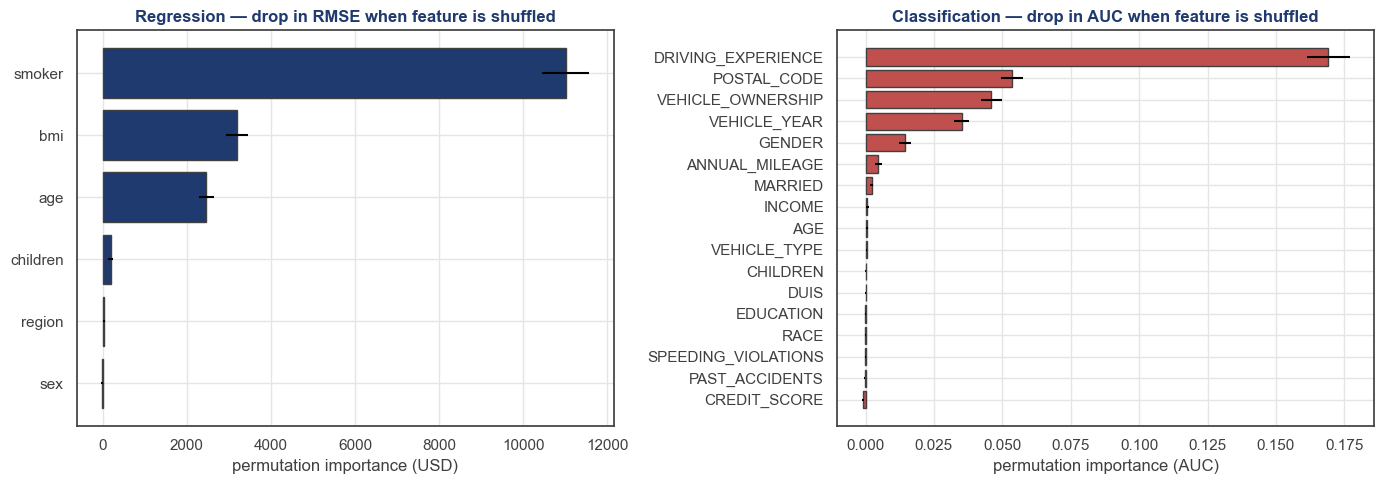

In [11]:
from sklearn.inspection import permutation_importance

# --- Regression: shuffle each column of X_test_r, measure drop in RMSE.
pi_r = permutation_importance(
    cb_reg, X_test_r, y_test_r,
    scoring="neg_root_mean_squared_error",
    n_repeats=30, random_state=SEED, n_jobs=-1,
)
pi_r_df = pd.DataFrame({
    "mean": pi_r.importances_mean,
    "std":  pi_r.importances_std,
}, index=X_test_r.columns).sort_values("mean", ascending=True)

# --- Classification: shuffle each column of X_test_c, measure drop in ROC AUC.
pi_c = permutation_importance(
    cb_cls, X_test_c, y_test_c,
    scoring="roc_auc",
    n_repeats=30, random_state=SEED, n_jobs=-1,
)
pi_c_df = pd.DataFrame({
    "mean": pi_c.importances_mean,
    "std":  pi_c.importances_std,
}, index=X_test_c.columns).sort_values("mean", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(pi_r_df.index, pi_r_df["mean"], xerr=pi_r_df["std"],
             color=PRIMARY, edgecolor=GRAY_TEXT)
axes[0].set_title("Regression — drop in RMSE when feature is shuffled")
axes[0].set_xlabel("permutation importance (USD)")

axes[1].barh(pi_c_df.index, pi_c_df["mean"], xerr=pi_c_df["std"],
             color=ACCENT_RED, edgecolor=GRAY_TEXT)
axes[1].set_title("Classification — drop in AUC when feature is shuffled")
axes[1].set_xlabel("permutation importance (AUC)")

fig.tight_layout()
plt.show()

**Reading the importances.**

- *Regression.* `smoker` dominates by a wide margin (shuffling it costs the model thousands of dollars of RMSE), then `bmi` and `age`. `children`, `sex`, and `region` are essentially noise on this small dataset.
- *Classification.* `DRIVING_EXPERIENCE` is the runaway top driver, followed by `POSTAL_CODE`, `VEHICLE_OWNERSHIP`, and `VEHICLE_YEAR`; `GENDER` is a smaller but non-zero contributor. The geographic `POSTAL_CODE` signal landing this high is worth a flag — it is a high-cardinality proxy that can smuggle in socio-economic effects, so it deserves a fairness check before production. `INCOME`, `CREDIT_SCORE`, and `PAST_ACCIDENTS` contribute almost nothing once the stronger features are present.

**A caveat.** Permutation importance tends to *over-credit correlated features* — if two features carry the same information, shuffling either alone still leaves the other in the model. For tightly correlated features, prefer SHAP global importance (§4.3) or group-permutation tests.

### 3.3 Partial dependence plots (PDP)

A PDP for feature *X* is built by sweeping a grid of values across *X*, and *for every value*, averaging the model's prediction across the rest of the portfolio (with all other features held at their actual observed values). The result is a curve showing the average effect of *X* on the prediction — the canonical *global* post-hoc method.

#### 1D PDPs — numerical features on both datasets

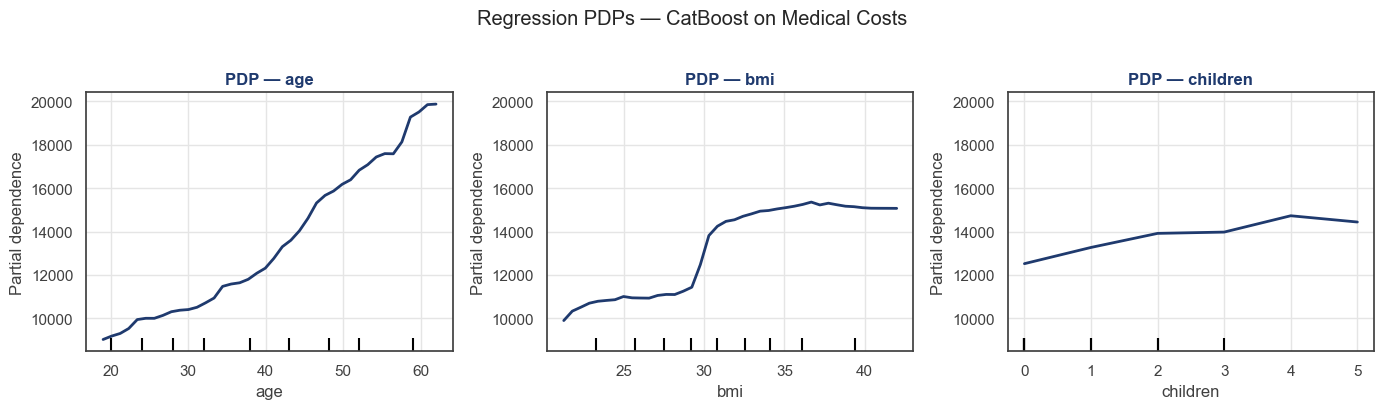

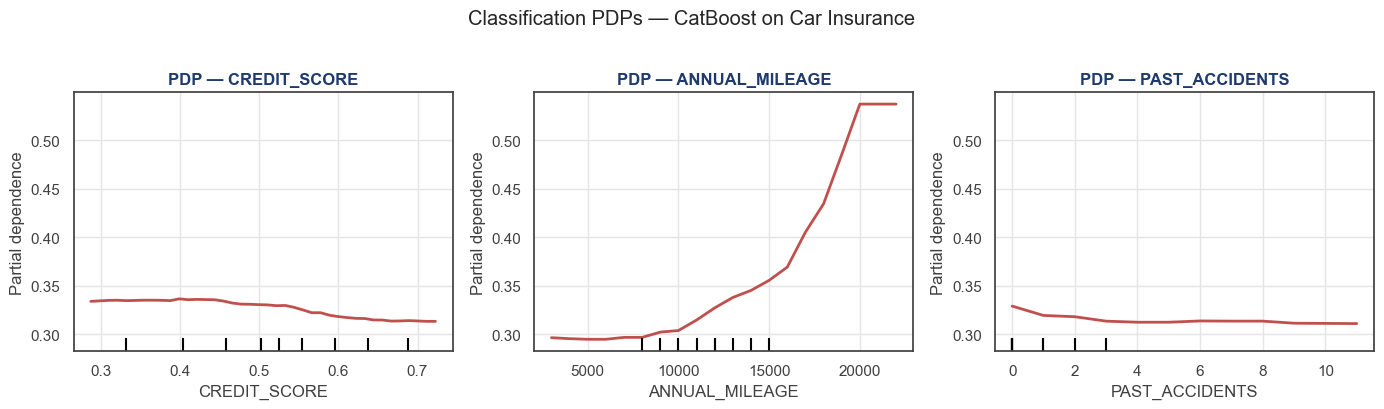

In [12]:
from sklearn.inspection import PartialDependenceDisplay

# `method='brute'` forces sklearn to call `.predict()` on grid points, which works
# uniformly for CatBoost; the default `method='auto'` may try the `'recursion'`
# fast-path that is only safe for sklearn's own tree ensembles.

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=num_cols_r,
    grid_resolution=40, ax=axes, method="brute",
    line_kw={"color": PRIMARY, "linewidth": 2.0},
)
for ax, name in zip(axes, num_cols_r):
    ax.set_title(f"PDP — {name}")
fig.suptitle("Regression PDPs — CatBoost on Medical Costs", y=1.02)
fig.tight_layout()
plt.show()

# Classification — pick the three continuous numerical features.
pdp_features_c = ["CREDIT_SCORE", "ANNUAL_MILEAGE", "PAST_ACCIDENTS"]
fig, axes = plt.subplots(1, len(pdp_features_c), figsize=(14, 4))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=pdp_features_c,
    grid_resolution=40, ax=axes, method="brute",
    response_method="predict_proba",
    line_kw={"color": ACCENT_RED, "linewidth": 2.0},
)
for ax, name in zip(np.atleast_1d(axes), pdp_features_c):
    ax.set_title(f"PDP — {name}")
fig.suptitle("Classification PDPs — CatBoost on Car Insurance", y=1.02)
fig.tight_layout()
plt.show()

**Reading the PDPs.**

- *Regression.* The PDP for `bmi` is the most striking — flat below the obesity threshold (≈ 30) and then steeply rising. `age` shows a smooth monotonic increase. `children` rises mildly up to about four children — the same gentle positive effect the linear regression showed.
- *Classification.* `CREDIT_SCORE` drifts gently downward (better credit → marginally fewer claims), but the effect is weak and noisy. `ANNUAL_MILEAGE` shows the expected strong increase — more kilometres, more claims. `PAST_ACCIDENTS` is **essentially flat**: once the stronger features are in the model it adds almost no marginal signal on this portfolio — consistent with its near-zero permutation importance above.

**PDP's blind spot — the independence assumption.** PDP averages over the *marginal* distribution of the other features, treating them as independent of the feature of interest. When features are correlated (e.g. `INCOME` and `EDUCATION` on Car Insurance), the PDP can place weight on feature combinations that barely occur in the data and so produce misleading curves. **Accumulated Local Effects (ALE) plots** are the standard remedy in exactly this setting — they average *local* changes over the conditional (rather than marginal) distribution, so correlated features no longer drag the curve into unobserved regions. ICE (§4.1) is complementary: it reveals the heterogeneity the PDP averages away.

#### 2D PDPs — feature interactions

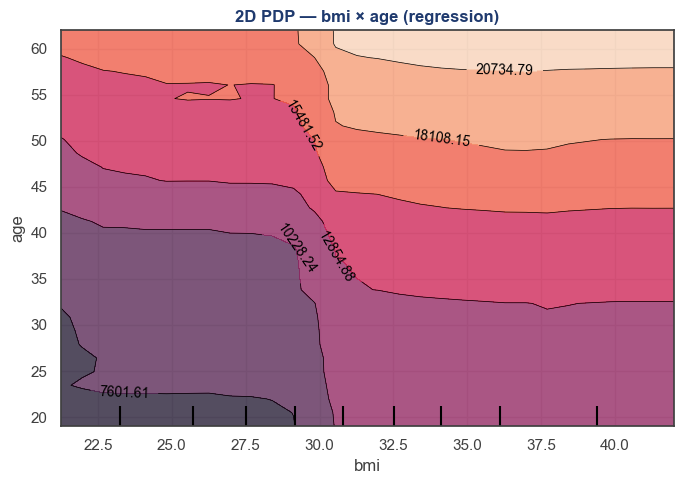

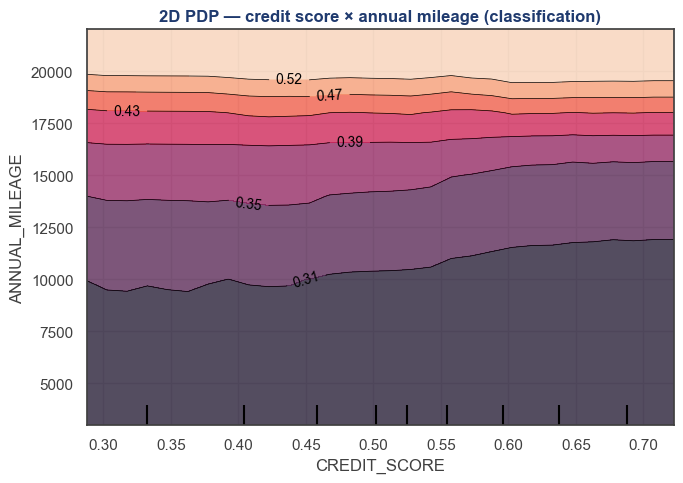

In [13]:
# Regression — bmi × age, two continuous features. (The headline smoker × bmi
# interaction would need a mixed continuous/categorical PDP, which sklearn does
# not support; we will pick that story up in the SHAP dependence plot in §4.3.)
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=[("bmi", "age")],
    grid_resolution=30, ax=ax, method="brute",
)
ax.set_title("2D PDP — bmi × age (regression)")
fig.tight_layout()
plt.show()

# Classification — credit score × annual mileage.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=[("CREDIT_SCORE", "ANNUAL_MILEAGE")],
    grid_resolution=30, ax=ax, method="brute",
    response_method="predict_proba",
)
ax.set_title("2D PDP — credit score × annual mileage (classification)")
fig.tight_layout()
plt.show()

**Reading the 2D PDPs.** Iso-contours that run *parallel to the axes* = no interaction (each feature's effect is independent of the other). Contours that *bend* = the two features interact.

- *Regression.* On the `bmi × age` surface the predicted charge rises with both variables; the BMI ≈ 30 jump shows up as a near-vertical contour that widens at older ages — a mild interaction on top of two strong main effects.
- *Classification.* The `CREDIT_SCORE × ANNUAL_MILEAGE` contours are almost horizontal: annual mileage drives the claim probability up strongly, while credit score barely moves it. The two effects are essentially additive, with little interaction.

> **A note on categorical × continuous interactions.** The headline interaction in the Medical Costs data is `smoker × bmi` (one categorical, one continuous), which sklearn's 2D PDP does not support directly. We will see that interaction crisply in the SHAP dependence plot in §4.3.

## 4. Local post-hoc methods

The §3 methods describe what the model does *on average*. They cannot answer the underwriter's question: *"why was **this specific policyholder** quoted that price?"*. The local-explanation family fills that gap.

Four methods:

- **ICE** — the per-instance version of PDP.
- **LIME** — fit a sparse linear model in the neighbourhood of one prediction.
- **SHAP** — distribute the model's prediction among its features using Shapley values from cooperative game theory. The standard local-and-global workhorse.
- **Counterfactuals** — find the *smallest* change to the inputs that would flip the prediction. Closely tied to the EU AI Act's *right to explanation*.

### 4.1 Individual conditional expectation (ICE)

An ICE plot shows the PDP curve *one policyholder at a time*. Take one row of the test set, sweep the feature of interest across its grid (everything else held at that row's actual values), and plot the model's predictions. Do this for every row → an ICE plot. The PDP is the *average* of the ICE curves.

ICE earns its keep when the curves *fan out* — that means the effect of the feature on the prediction depends on the rest of the policyholder's profile, and the PDP would average that heterogeneity away.

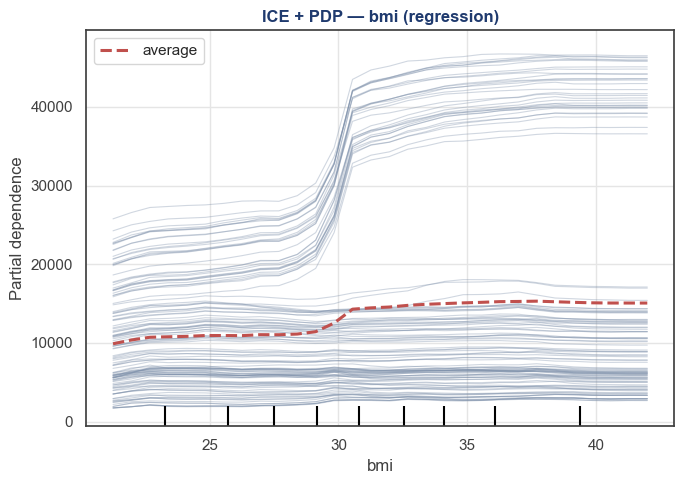

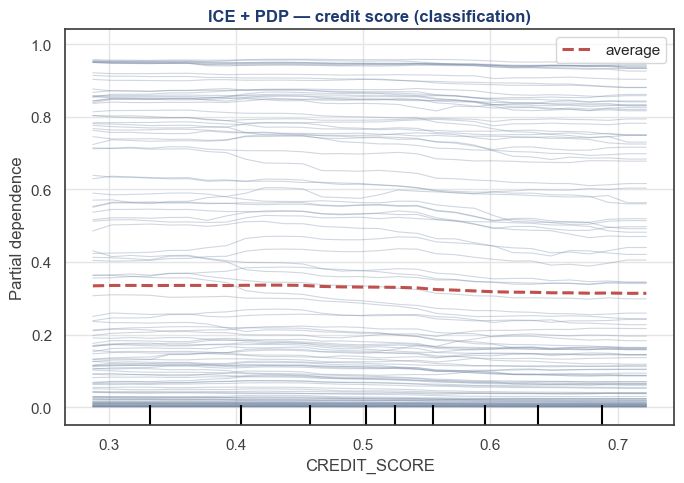

In [14]:
# ICE shows the prediction curve for one policyholder at a time; the PDP is their average.
from matplotlib.lines import Line2D

# Regression — BMI is the feature where smoker × bmi heterogeneity matters most.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_reg, X_test_r, features=["bmi"], kind="both",
    grid_resolution=30, method="brute",
    subsample=120, random_state=SEED, ax=ax,
    ice_lines_kw={"color": "#7A8DA8", "alpha": 0.35, "linewidth": 0.8},
    pd_line_kw={"color": ACCENT_RED, "linewidth": 2.2},
)
ax.set_title("ICE + PDP — bmi (regression)")
# Build the legend from proxy artists so it never depends on the display's internal labels.
ax.legend(handles=[
    Line2D([0], [0], color=ACCENT_RED, lw=2.2, label="PDP (average)"),
    Line2D([0], [0], color="#7A8DA8", lw=0.8, label="ICE (per policyholder)"),
], loc="upper left")
fig.tight_layout()
plt.show()

# Classification — credit score across a sub-sample.
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(
    cb_cls, X_test_c, features=["CREDIT_SCORE"], kind="both",
    grid_resolution=30, method="brute",
    subsample=120, random_state=SEED, ax=ax,
    ice_lines_kw={"color": "#7A8DA8", "alpha": 0.35, "linewidth": 0.8},
    pd_line_kw={"color": ACCENT_RED, "linewidth": 2.2},
)
ax.set_title("ICE + PDP — credit score (classification)")
ax.legend(handles=[
    Line2D([0], [0], color=ACCENT_RED, lw=2.2, label="PDP (average)"),
    Line2D([0], [0], color="#7A8DA8", lw=0.8, label="ICE (per policyholder)"),
], loc="upper right")
fig.tight_layout()
plt.show()

**Reading the ICE plots.**

- *Regression.* The grey ICE curves split into two clear bundles — a steep upper bundle and a shallow lower one, the smoker and non-smoker sub-populations. The red dashed PDP curve runs between them; on its own it would hide the heterogeneity. **This is the lesson: a single PDP curve can mask a population that behaves in two very different ways.**
- *Classification.* The ICE curves are far more uniform — credit score has a similar, gently declining effect for everyone, with only mild fanning. **No bimodal pattern**, so here the PDP is a faithful summary.

### 4.2 LIME — Local Interpretable Model-Agnostic Explanations

LIME picks one instance, generates *perturbed* versions of it (random shuffles of feature values), asks the black box to predict each perturbed instance, and fits a sparse linear model on those perturbed predictions weighted by their similarity to the original. The fitted linear model's coefficients are LIME's local explanation.

#### LIME on Medical Costs (regression)

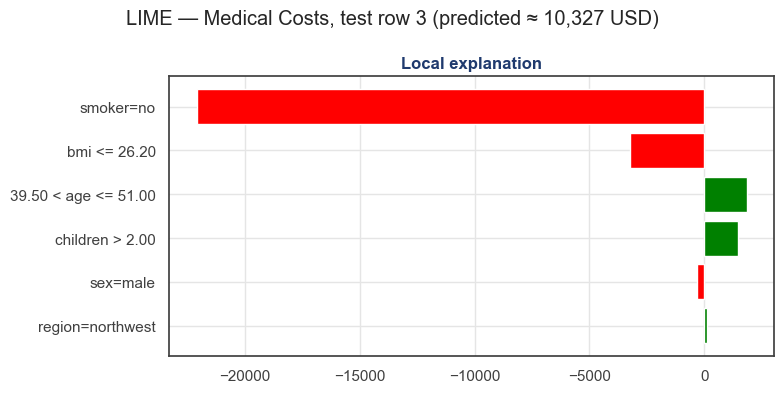

Instance:
age                46
sex              male
bmi            25.745
children            3
smoker             no
region      northwest
Name: 1293, dtype: object


In [15]:
from lime.lime_tabular import LimeTabularExplainer
from sklearn.preprocessing import LabelEncoder

# LIME needs purely numeric input. Label-encode the categoricals, then wrap the
# CatBoost regressor's `predict` in a function that inverse-transforms back to the
# raw form CatBoost was trained on.
label_encoders_r = {c: LabelEncoder().fit(X_reg[c]) for c in cat_cols_r}

def encode_r(X):
    out = X.copy()
    for c, le in label_encoders_r.items():
        out[c] = le.transform(out[c])
    return out

def decode_r(X_array, columns):
    df = pd.DataFrame(X_array, columns=columns)
    for c, le in label_encoders_r.items():
        df[c] = le.inverse_transform(df[c].astype(int))
    return df

X_train_r_le = encode_r(X_train_r)
X_test_r_le  = encode_r(X_test_r)

cat_idx_r = [X_train_r_le.columns.get_loc(c) for c in cat_cols_r]
cat_names_r = {
    X_train_r_le.columns.get_loc(c): list(le.classes_)
    for c, le in label_encoders_r.items()
}

explainer_lime_r = LimeTabularExplainer(
    X_train_r_le.values,
    feature_names=X_train_r_le.columns.tolist(),
    mode="regression",
    categorical_features=cat_idx_r,
    categorical_names=cat_names_r,
    random_state=SEED,
)

def predict_r(arr):
    return cb_reg.predict(decode_r(arr, X_train_r_le.columns))

# Pick one test instance.
i_r = 3
exp_lime_r = explainer_lime_r.explain_instance(
    X_test_r_le.iloc[i_r].values, predict_r, num_features=6
)
fig = exp_lime_r.as_pyplot_figure()
fig.set_size_inches(8, 4)
fig.suptitle(f"LIME — Medical Costs, test row {i_r} (predicted ≈ {cb_reg.predict(X_test_r.iloc[[i_r]])[0]:,.0f} USD)")
fig.tight_layout()
plt.show()

print("Instance:")
print(X_test_r.iloc[i_r])

**Reading the LIME explanation.** Each bar is one feature's contribution to the prediction for this single policyholder — a 46-year-old non-smoker. `smoker = no` pushes the predicted charge sharply **down** (by far the largest bar) and the below-30 BMI pushes it down further; `age` and having three `children` nudge it back up. The magnitudes are the *local* linear coefficients LIME fits in a small neighbourhood around this row, so they answer "what drove *this* prediction", not "what the model does on average".

#### LIME on Car Insurance (classification)

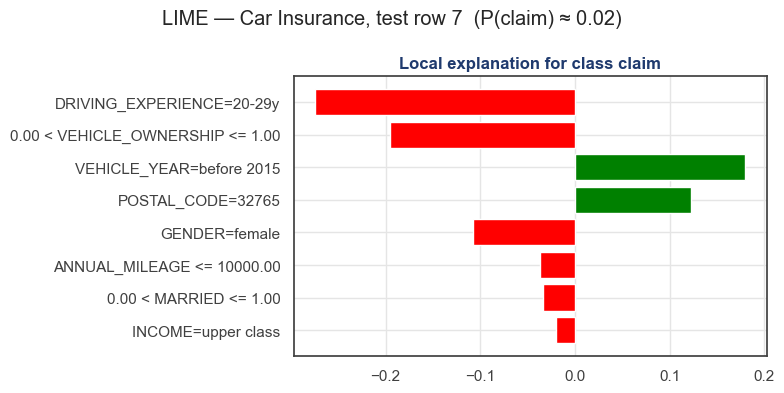

Instance:
AGE                          40-64
GENDER                      female
RACE                      majority
DRIVING_EXPERIENCE          20-29y
EDUCATION              high school
INCOME                 upper class
CREDIT_SCORE              0.564942
VEHICLE_OWNERSHIP              1.0
VEHICLE_YEAR           before 2015
MARRIED                        1.0
CHILDREN                       1.0
POSTAL_CODE                  32765
ANNUAL_MILEAGE              8000.0
VEHICLE_TYPE                 sedan
SPEEDING_VIOLATIONS              2
DUIS                             0
PAST_ACCIDENTS                   1
Name: 8435, dtype: object


In [16]:
label_encoders_c = {c: LabelEncoder().fit(X_cls[c]) for c in cat_cols_c}

def encode_c(X):
    out = X.copy()
    for c, le in label_encoders_c.items():
        out[c] = le.transform(out[c])
    return out

def decode_c(X_array, columns):
    df = pd.DataFrame(X_array, columns=columns)
    for c, le in label_encoders_c.items():
        df[c] = le.inverse_transform(df[c].astype(int))
    for c in num_cols_c:
        df[c] = df[c].astype(float)
    return df

X_train_c_le = encode_c(X_train_c)
X_test_c_le  = encode_c(X_test_c)

cat_idx_c = [X_train_c_le.columns.get_loc(c) for c in cat_cols_c]
cat_names_c = {
    X_train_c_le.columns.get_loc(c): list(le.classes_)
    for c, le in label_encoders_c.items()
}

explainer_lime_c = LimeTabularExplainer(
    X_train_c_le.values,
    feature_names=X_train_c_le.columns.tolist(),
    mode="classification",
    class_names=["no claim", "claim"],
    categorical_features=cat_idx_c,
    categorical_names=cat_names_c,
    random_state=SEED,
)

def predict_c(arr):
    return cb_cls.predict_proba(decode_c(arr, X_train_c_le.columns))

i_c = 7
exp_lime_c = explainer_lime_c.explain_instance(
    X_test_c_le.iloc[i_c].values, predict_c, num_features=8
)
fig = exp_lime_c.as_pyplot_figure()
fig.set_size_inches(8, 4)
fig.suptitle(
    f"LIME — Car Insurance, test row {i_c}  "
    f"(P(claim) ≈ {cb_cls.predict_proba(X_test_c.iloc[[i_c]])[0, 1]:.2f})"
)
fig.tight_layout()
plt.show()

print("Instance:")
print(X_test_c.iloc[i_c])

**Reading the LIME explanation.** Same logic, classification version — but note this is a *low-risk* policyholder, with a predicted claim probability of only ≈ 0.02. In LIME's class-`claim` view, red bars push the claim probability **down** and green bars push it **up**. Here the two largest bars — `DRIVING_EXPERIENCE = 20-29y` and owning the vehicle (`VEHICLE_OWNERSHIP`) — are both red, i.e. they pull the claim probability down; an older `VEHICLE_YEAR` and the postal code push mildly the other way. The actuarial reading is concrete: *"this policyholder is assessed as low risk because they are an experienced driver who owns their vehicle"* — a defensible, customer-facing explanation.

**LIME's caveats.** The fitted local model is *not* the black box — its coefficients depend on the choice of perturbation strategy and kernel width. For tabular data with mostly categorical features, SHAP (next) tends to give more stable and more theoretically grounded explanations.

### 4.3 SHAP — Shapley Additive Explanations

SHAP assigns each feature a value equal to its **average marginal contribution** to the prediction across all possible feature orderings — a concept from cooperative game theory. Two structural properties make SHAP the de-facto industry standard:

1. **Local accuracy** — the SHAP values for one instance sum to *exactly* the prediction (minus the base rate). No leftover, no rounding.
2. **Consistency** — if you change the model so that a feature contributes more, its SHAP value cannot decrease.

For a tree-based model like CatBoost, `shap.TreeExplainer` computes exact SHAP values in milliseconds — orders of magnitude faster than the slower, model-agnostic `KernelExplainer` you may see in older notebooks.

#### Local SHAP — waterfall plots for one policyholder per dataset

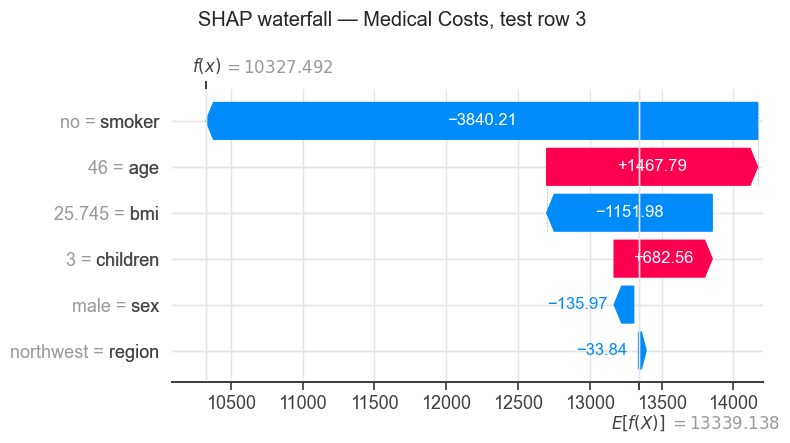

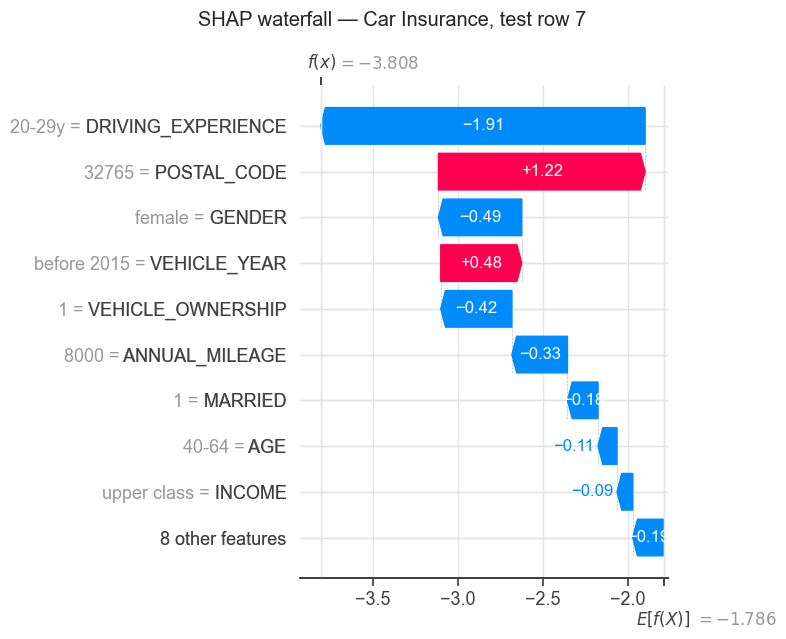

In [17]:
import shap

# TreeExplainer gives exact SHAP values for tree ensembles like CatBoost, in milliseconds.
# --- Regression: build the explainer and compute SHAP values for every test row.
expl_reg = shap.TreeExplainer(cb_reg)
shap_reg = expl_reg(X_test_r)   # shap.Explanation object, length = n_test

# Waterfall: how each feature moves THIS policyholder from the base value to f(x).
fig = plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(shap_reg[i_r], max_display=10, show=False)
plt.suptitle(f"SHAP waterfall — Medical Costs, test row {i_r}")
plt.tight_layout()
plt.show()

# --- Classification: same recipe. Pass the raw test frame so SHAP picks up CatBoost's
#     native categorical handling; SHAP values are in log-odds here.
expl_cls = shap.TreeExplainer(cb_cls)
shap_cls = expl_cls(X_test_c)

fig = plt.figure(figsize=(8, 4.5))
shap.plots.waterfall(shap_cls[i_c], max_display=10, show=False)
plt.suptitle(f"SHAP waterfall — Car Insurance, test row {i_c}")
plt.tight_layout()
plt.show()

**Reading the waterfall.** Start from the *base value* (the model's average prediction on the test set, shown as E[f(X)]). Each bar adds or subtracts that feature's SHAP value for this policyholder; the bars sum exactly to the prediction f(x) at the top.

- *Regression (test row 3).* This is the same non-smoker as in the LIME example. `smoker = no` (−3,956 USD) and the below-30 `bmi` (−1,222 USD) pull the prediction below the 13,339 USD portfolio average, while `age` (+1,101 USD) and `children` (+596 USD) push back up — landing at ≈ 9,698 USD. The customer-facing reading: *"your predicted charge is below the portfolio average mainly because you are a non-smoker (−3,956 USD) with a BMI under 30 (−1,222 USD)."*
- *Classification (test row 7).* Working in log-odds: `DRIVING_EXPERIENCE = 20-29y` (≈ −2.1) does the heavy lifting downward, `POSTAL_CODE` (≈ +1.5) pushes up, then `GENDER`, `VEHICLE_YEAR`, and `VEHICLE_OWNERSHIP`. The bars sum to a log-odds of about −3.9, which the model converts back to the low ≈ 0.02 claim probability.

#### Global SHAP — beeswarm and bar summaries

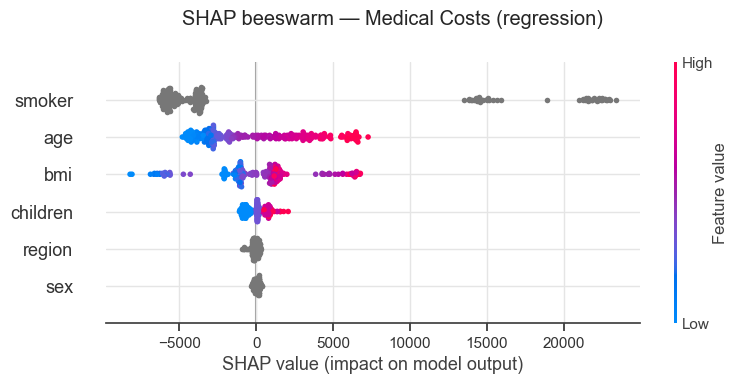

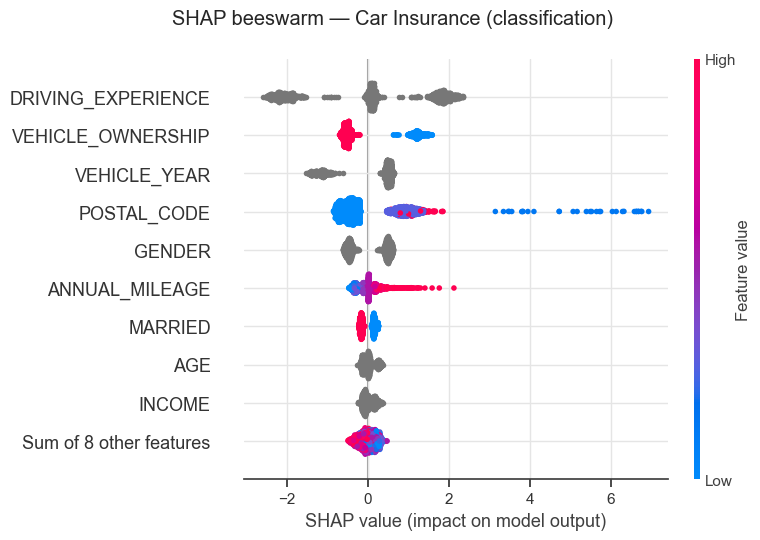

In [18]:
# Beeswarm: every dot is one (feature, policyholder) pair; colour shows feature value;
# x-axis shows that policyholder's SHAP value for that feature. Top-down ordering is by
# global mean(|SHAP|).
fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_reg, max_display=8, show=False)
plt.suptitle("SHAP beeswarm — Medical Costs (regression)")
plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_cls, max_display=10, show=False)
plt.suptitle("SHAP beeswarm — Car Insurance (classification)")
plt.tight_layout()
plt.show()

**Reading the beeswarm.** Each row is one feature, ordered by global importance (mean |SHAP|). Each dot is one test-set policyholder; its horizontal position is that policyholder's SHAP value for that feature; the colour is the feature's value (red = high, blue = low; categorical features such as `smoker` and `DRIVING_EXPERIENCE` are shown in grey). A *vertical spread* of dots = heterogeneity; a *colour gradient along x* = the direction of the effect.

- *Regression.* `smoker` is a clean bimodal split — non-smokers bunched at a small negative SHAP value, smokers flung far to the right (+15,000 to +23,000 USD). `age` shows a smooth blue→red gradient, and `bmi` carries the smoker × BMI interaction we keep meeting.
- *Classification.* `DRIVING_EXPERIENCE` is the strongest separator, and `VEHICLE_OWNERSHIP` shows a clean owner/non-owner split. `POSTAL_CODE` has a striking long right tail — a handful of postal codes that multiply the claim odds. Note that `GENDER` carries a clearly non-trivial spread (≈ ±0.5 in log-odds) — in a real pricing model that would warrant a fairness review; the genuinely negligible features here are `RACE` and `VEHICLE_TYPE`.

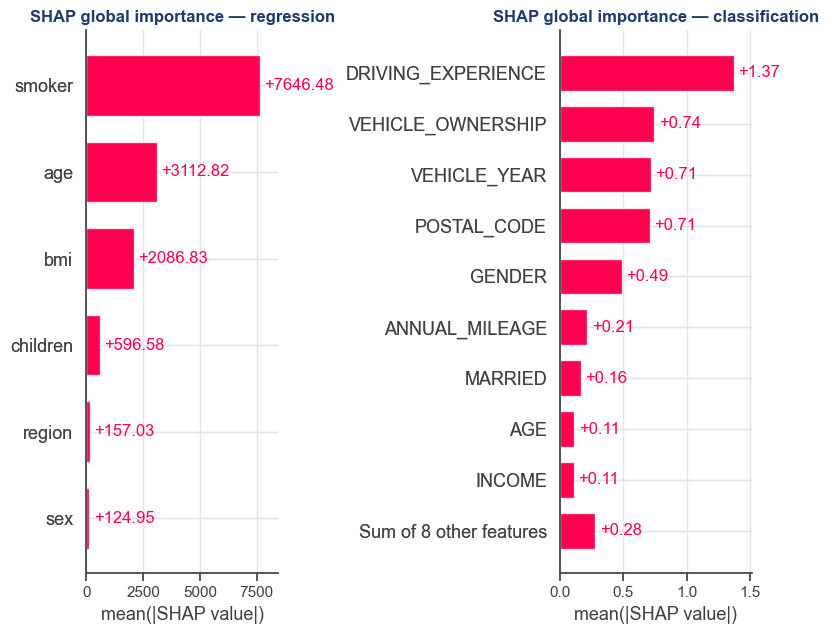

In [19]:
# Bar plot: the bar height = mean(|SHAP|) per feature, i.e. the SHAP-based global importance.
# Compare directly with the permutation-importance bars from §3.2.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(axes[0])
shap.plots.bar(shap_reg, max_display=8, show=False)
axes[0].set_title("SHAP global importance — regression")

plt.sca(axes[1])
shap.plots.bar(shap_cls, max_display=10, show=False)
axes[1].set_title("SHAP global importance — classification")

fig.tight_layout()
plt.show()

**Reading the bar plots.** The rankings broadly match permutation importance (§3.2) but the magnitudes are interpretable in **prediction units** — dollars for the regressor, log-odds for the classifier. **SHAP is the single workhorse you need on most tabular projects** — the same explainer gives you per-instance attribution *and* portfolio-level importance, all in one consistent framework.

#### SHAP dependence plot — interactions revealed

<Figure size 700x500 with 0 Axes>

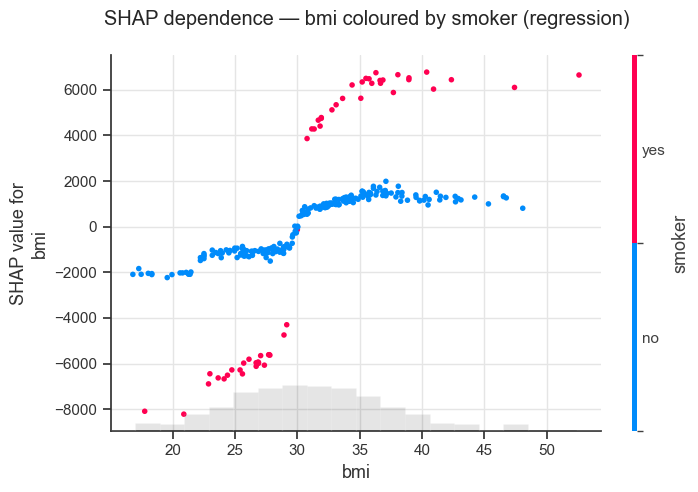

In [20]:
# SHAP dependence: x = BMI, y = BMI's SHAP value, colour = smoker status.
# Colouring by a second feature is how a SHAP dependence plot surfaces interactions.
fig = plt.figure(figsize=(7, 5))
shap.plots.scatter(shap_reg[:, "bmi"], color=shap_reg[:, "smoker"], show=False)
plt.suptitle("SHAP dependence — bmi coloured by smoker (regression)")
plt.tight_layout()
plt.show()

**Reading the SHAP dependence plot.** Each dot is one test-set policyholder; the *x*-axis is their BMI; the *y*-axis is the SHAP value for BMI (its contribution to that policyholder's predicted charge). The dots are coloured by the policyholder's smoker status. **Two clean bands emerge** — non-smokers (blue) sit near zero across the BMI range; smokers (red) climb steeply with BMI. This is the smoker × BMI interaction made *visible* — and it is exactly the artefact an underwriter would point to when explaining why two policyholders with the same BMI receive different quotes.

### 4.4 Counterfactual explanations

A counterfactual asks the opposite question of every other method we have used: *"What is the **smallest change** I would need to make to this policyholder's features to flip the prediction?"*. The output is not a coefficient or a SHAP value — it is **a list of alternative policyholder profiles** that would have been classified the other way.

This is the form of explanation the EU AI Act's *right to explanation* lines up most directly with: a customer who is denied coverage (or quoted a high premium) gets an actionable, concrete answer to *"what would have to be different about me for the decision to change?"*.

We use `dice-ml` with `method="random"` for speed; the recipe carries over to more sophisticated methods (`method="genetic"`, `method="kdtree"`) if the random sampler does not converge.

In [21]:
import dice_ml

# DiCE expects the *training frame* including the outcome column.
dice_df = pd.concat([X_train_c, y_train_c.rename(target_cls)], axis=1)

# Wrap the data and the trained classifier in DiCE's interfaces.
dice_data = dice_ml.Data(
    dataframe=dice_df,
    continuous_features=num_cols_c,
    outcome_name=target_cls,
)
dice_model = dice_ml.Model(model=cb_cls, backend="sklearn", model_type="classifier")
dice_explainer = dice_ml.Dice(dice_data, dice_model, method="random")

# Generate 3 counterfactuals that flip the prediction for our low-risk policyholder.
# method="random" samples stochastically — seed numpy just before the call for reproducibility.
np.random.seed(SEED)
cf = dice_explainer.generate_counterfactuals(
    X_test_c.iloc[[i_c]],
    total_CFs=3,
    desired_class="opposite",
    random_seed=SEED,
)
cf.visualize_as_dataframe(show_only_changes=True)

100%|██████████| 1/1 [00:00<00:00, 14.01it/s]

Query instance (original outcome : 0)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,40-64,female,majority,20-29y,high school,upper class,0.564942,1.0,before 2015,1.0,1.0,32765,8000.0,sedan,2,0,1,0



Diverse Counterfactual set (new outcome: 1)


,AGE,GENDER,RACE,DRIVING_EXPERIENCE,EDUCATION,INCOME,CREDIT_SCORE,VEHICLE_OWNERSHIP,VEHICLE_YEAR,MARRIED,CHILDREN,POSTAL_CODE,ANNUAL_MILEAGE,VEHICLE_TYPE,SPEEDING_VIOLATIONS,DUIS,PAST_ACCIDENTS,OUTCOME
0,-,-,-,0-9y,-,-,-,-,-,-,-,-,-,-,-,5,-,1
1,-,-,-,-,-,-,-,-,-,-,-,21217,-,-,4,-,-,1
2,-,-,-,-,-,-,-,-,-,-,-,21217,-,-,-,-,11,1


**Reading the counterfactuals.** The query instance is our low-risk policyholder (predicted outcome 0, *no claim*). Each row of the counterfactual set is a minimally-changed profile that flips the model to *claim* (outcome 1) — only the changed cells are shown. Every change pushes the profile toward higher risk: fewer years of driving experience, a higher-risk `POSTAL_CODE`, or more recorded incidents (speeding violations, DUIs, past accidents). Any one such edit is enough to flip the prediction — exactly the concrete, defensible answer to *"what would have to be different for the decision to change?"* that a customer-facing system needs.

**Three caveats actuaries care about.**

- *Actionability.* DiCE will happily change immutable or insurer-set attributes (`POSTAL_CODE` is not something the customer chooses for pricing purposes). Use the `features_to_vary` parameter to restrict the search to genuinely *modifiable* features — Exercise 3 does exactly this.
- *Plausibility.* A counterfactual that lives far outside the training-data manifold (e.g. an 18-year-old with 30 years of driving experience) is not a usable explanation. `method="kdtree"` finds counterfactuals among *actual* training-set neighbours and avoids this trap.
- *Reproducibility.* `method="random"` samples stochastically; we seed it just before the call so the notebook reproduces, but a different seed yields a different — equally valid — set of counterfactuals.

## 5. Putting it together — when to use which method

Every method covered, placed on the (global ↔ local) × (intrinsic ↔ post-hoc) grid, with a one-line "use this when…" prompt:

| Method | Scope | Type | Use this when… |
|---|---|---|---|
| **Linear / logistic coefficients** | Global | Intrinsic | …the model itself is intrinsically interpretable and you trust its functional form. |
| **Decision-tree structure** | Global | Intrinsic | …you can pre-commit to a tree-based model with limited depth. |
| **Global surrogate (tree)** | Global | Post-hoc | …you want a transparent summary of a black box; tree captures interactions. |
| **Global surrogate (linear/logistic)** | Global | Post-hoc | …you want signed effects from a black box for a regulatory report. |
| **Permutation feature importance** | Global | Post-hoc | …you want a quick *which features matter* ranking; uncorrelated features. |
| **Partial dependence plot** | Global | Post-hoc | …you want the average *shape* of one feature's effect on the prediction. |
| **2D PDP** | Global | Post-hoc | …you suspect (or want to demonstrate) an interaction between two features. |
| **ICE** | Local | Post-hoc | …you suspect the PDP averages away meaningful heterogeneity. |
| **LIME** | Local | Post-hoc | …you want a per-instance linear explanation in a familiar coefficient form. |
| **SHAP** | Local + Global | Post-hoc | …default workhorse — works for one instance *and* aggregates to global summaries. |
| **Counterfactual** | Local | Post-hoc | …a customer asks *"what would have to be different about me to get a different decision?"*. |

**One concrete pipeline for the actuarial setting.** During model development → PDP + SHAP beeswarm to validate that the model behaviour matches actuarial intuition. During model validation → global surrogate tree + permutation feature importance as part of the validation report. In production, for every customer-facing decision → SHAP waterfall + counterfactual as the explanation pair (SHAP for *why*, counterfactual for *what to change*).

## Exercises

Three exercises, each self-contained — copy, modify, re-run.

### Exercise 1 — SHAP global importance vs. permutation importance

Permutation feature importance and SHAP global importance (mean |SHAP|) are both *global* rankings, but they are measured in **different units** — mean |SHAP| is in the model's output units (here log-odds), permutation importance is in the scoring metric (here AUC points). So do **not** compare the two columns' raw magnitudes; compare their **rankings**. Compute SHAP global importance for the classification model, line it up against the permutation-importance top-5 from §3.2, and ask: where do they agree, where do they disagree, and why?

In [22]:
# Exercise 1 starter — SHAP global ranking vs. permutation ranking.
shap_glob = (
    pd.Series(np.abs(shap_cls.values).mean(0), index=X_test_c.columns,
              name="mean|SHAP|")
      .sort_values(ascending=False)
      .head(5)
)
perm_glob = (
    pd.Series(pi_c.importances_mean, index=X_test_c.columns,
              name="permutation Δ AUC")
      .sort_values(ascending=False)
      .head(5)
)
pd.concat([shap_glob, perm_glob], axis=1).style.format("{:.4f}")

,mean|SHAP|,permutation Δ AUC
DRIVING_EXPERIENCE,1.3728,0.1692
VEHICLE_OWNERSHIP,0.7445,0.0459
VEHICLE_YEAR,0.7140,0.0351
POSTAL_CODE,0.7061,0.0536
GENDER,0.4882,0.0143


In [23]:
# Solution — the two methods agree on the top-5 *set* here, but report it in different units.
# mean|SHAP| is in log-odds (the model's output scale); permutation importance is in AUC
# points. So the big gap between the two columns' raw numbers is expected — only the
# *rankings* are comparable. They diverge most for *correlated* features: permutation
# over-credits whichever is shuffled first (the others still proxy for it), while SHAP
# splits the credit more evenly via the Shapley rule.
common    = sorted(set(shap_glob.index) & set(perm_glob.index))
only_shap = sorted(set(shap_glob.index) - set(perm_glob.index))
only_perm = sorted(set(perm_glob.index) - set(shap_glob.index))
print(f"In both top-5:     {common}")
print(f"Only SHAP top-5:   {only_shap}")
print(f"Only perm top-5:   {only_perm}")
print("Units differ (log-odds vs AUC) — compare rankings, not raw magnitudes.")
print("Rule of thumb: triangulate. If both methods agree, trust the ranking.")

In both top-5:     ['DRIVING_EXPERIENCE', 'GENDER', 'POSTAL_CODE', 'VEHICLE_OWNERSHIP', 'VEHICLE_YEAR']
Only SHAP top-5:   []
Only perm top-5:   []
Units differ (log-odds vs AUC) — compare rankings, not raw magnitudes.
Rule of thumb: triangulate. If both methods agree, trust the ranking.


### Exercise 2 — PDP of `age` broken down by `smoker`

PDP is a *global* method, but a *grouped* PDP — one PDP curve per value of a second feature — is a useful diagnostic for non-additivity. Compute and plot the PDP of `age` on the regression model **separately for smokers and non-smokers**, and read it as evidence for an `age × smoker` interaction (or lack thereof).

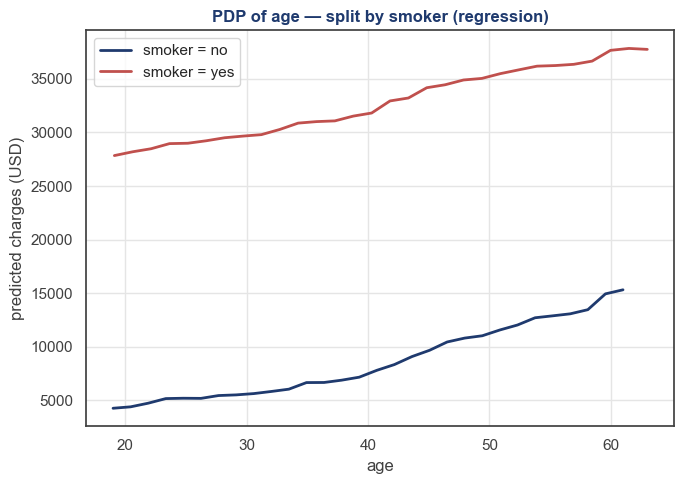

In [24]:
# Exercise 2 starter — PDP of `age` grouped by `smoker`. We compute the partial
# dependence manually on each subset so we can stack the two curves on a single axis.
from sklearn.inspection import partial_dependence

fig, ax = plt.subplots(figsize=(7, 5))
for smoker_val, colour in [("no", PRIMARY), ("yes", ACCENT_RED)]:
    mask = X_test_r["smoker"] == smoker_val
    pd_result = partial_dependence(
        cb_reg, X_test_r[mask], features=["age"],
        grid_resolution=30, method="brute",
    )
    ax.plot(
        pd_result["grid_values"][0], pd_result["average"][0],
        color=colour, lw=2.0, label=f"smoker = {smoker_val}",
    )

ax.set_xlabel("age")
ax.set_ylabel("predicted charges (USD)")
ax.set_title("PDP of age — split by smoker (regression)")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

In [25]:
# Solution — clear age × smoker interaction (non-additive on charges)
# The PDP for smokers rises roughly 3× faster with age than the non-smoker curve.
# That's textbook non-additivity: the marginal age effect depends on smoker.
# A linear model with main effects only cannot capture this — you'd need an explicit
# age × smoker interaction term. CatBoost finds the interaction for free, which is
# part of why tree ensembles outperform additive GLMs on this kind of tabular signal.
print("Verdict: pronounced age × smoker interaction.")
print("  • non-smokers: gentle, roughly linear age effect")
print("  • smokers:     steeper rise, especially past age ~45")
print("Implication: a linear actuarial model on this data needs an explicit interaction.")

Verdict: pronounced age × smoker interaction.
  • non-smokers: gentle, roughly linear age effect
  • smokers:     steeper rise, especially past age ~45
Implication: a linear actuarial model on this data needs an explicit interaction.


### Exercise 3 — Actionable counterfactuals

Modify the DiCE call from §4.4 so that the counterfactuals can only vary **`ANNUAL_MILEAGE`, `VEHICLE_OWNERSHIP`, `VEHICLE_YEAR`, and `CREDIT_SCORE`** — features a customer can plausibly change. Generate counterfactuals for the same `i_c` instance and compare them against the unrestricted counterfactuals from §4.4.

> **Hint.** Pass `features_to_vary=[...]` to `generate_counterfactuals`. For this very low-risk policyholder you may well find that *no* actionable flip exists — that is a legitimate and instructive outcome, not an error (the `try/except` below handles it gracefully). To force a flip, widen `features_to_vary`, relax `permitted_range`, or pick a borderline policyholder whose predicted claim probability is near 0.5.

In [26]:
# Exercise 3 starter — restrict the counterfactual search to "actionable" features
# (ones a customer can plausibly change).
actionable = ["ANNUAL_MILEAGE", "VEHICLE_OWNERSHIP", "VEHICLE_YEAR", "CREDIT_SCORE"]
np.random.seed(SEED)  # reproducibility for the stochastic random sampler
try:
    cf_actionable = dice_explainer.generate_counterfactuals(
        X_test_c.iloc[[i_c]],
        total_CFs=3,
        desired_class="opposite",
        features_to_vary=actionable,
        random_seed=SEED,
    )
    cf_actionable.visualize_as_dataframe(show_only_changes=True)
except Exception as exc:
    # For this robustly low-risk policyholder, none of the customer-changeable features
    # is enough to flip the decision — a valid finding, not a bug.
    print("No actionable counterfactual found for this policyholder.")
    print("None of the customer-changeable features (mileage, ownership, vehicle year,")
    print("credit score) is enough to flip the model's low-risk verdict.")
    print("To force a flip: widen `features_to_vary`, relax `permitted_range`,")
    print("or switch to method='kdtree' (searches actual training-set neighbours).")

100%|██████████| 1/1 [00:00<00:00, 14.25it/s]

No Counterfactuals found for the given configuration, perhaps try with different parameters... ; total time taken: 00 min 00 sec
No actionable counterfactual found for this policyholder.
None of the customer-changeable features (mileage, ownership, vehicle year,
credit score) is enough to flip the model's low-risk verdict.
To force a flip: widen `features_to_vary`, relax `permitted_range`,
or switch to method='kdtree' (searches actual training-set neighbours).


In [27]:
# Solution — for THIS low-risk policyholder, no actionable flip exists.
# The unrestricted search in 4.4 flipped the prediction only by editing features the
# customer cannot act on (driving-experience band, postal code, past incidents).
# Restricting to genuinely actionable features (mileage, ownership, vehicle year,
# credit score) yields NO counterfactual: the model's low-risk verdict is robust to
# everything the customer could realistically change. That is an honest, defensible
# message — and a reminder that counterfactual *feasibility* is itself information.
print("Unrestricted CFs (4.4): flips exist, but only via non-actionable features.")
print("Actionable-only CFs:     none found — the low-risk verdict is robust.")
print("Takeaway: 'no actionable counterfactual' is a valid, informative result,")
print("not a bug. Widen the feature set or pick a borderline case to force a flip.")

Unrestricted CFs (4.4): flips exist, but only via non-actionable features.
Actionable-only CFs:     none found — the low-risk verdict is robust.
Takeaway: 'no actionable counterfactual' is a valid, informative result,
not a bug. Widen the feature set or pick a borderline case to force a flip.


## Summary

- **Intrinsic interpretation is free but limited.** Linear, logistic, and shallow-tree models hand you the explanation as part of their structure — at the cost of model capacity. Use them as a *baseline*, not a stopping point.
- **Global post-hoc methods** open the black box on a *portfolio* scale. Surrogate models give a transparent summary (tree for interactions, linear/logistic for signed effects); permutation importance gives a quick ranking; PDP gives the average shape of each feature's effect (and ICE rescues the heterogeneity PDP averages away).
- **Local post-hoc methods** explain individual predictions. LIME and SHAP both attribute the prediction to its features, but SHAP is more stable, more theoretically grounded, and — for tree models — orders of magnitude faster than LIME. **SHAP is the single workhorse you should reach for first.**
- **Counterfactuals** are the explanation form most closely aligned with the EU AI Act's *right to explanation* — they give a customer an actionable answer to *"what would have to be different for the decision to change?"*. Use them in tandem with SHAP for full coverage.
- **Every method has assumptions and blind spots.** PDP assumes feature independence; permutation importance over-credits correlated features; LIME is sensitive to its perturbation strategy; counterfactuals can be unrealistic if not constrained. **Triangulate** — use at least two methods to confirm any explanation that will inform a business decision.

## Next steps

Continue with [Section 4 — Special Topics in Machine Learning](../04_special_topics_ml/04_special_topics_ml.ipynb), where calibration, fairness, and uncertainty quantification extend the interpretability story to the rest of the production-ML toolkit.

## References

- Molnar, C. (2025). *Interpretable Machine Learning — A Guide for Making Black Box Models Explainable* (3rd ed.). <https://christophm.github.io/interpretable-ml-book/>. The canonical free reference for every method in this notebook.
- DAV Arbeitsgruppe *Explainable AI*, Unterarbeitsgruppe 2: *Model-Agnostic Interpretability Methods — Toy Examples* (Python notebooks for Car Insurance classification and Medical Costs regression). The starting point for this notebook's code patterns.
- EIOPA (2021). *Artificial Intelligence Governance Principles — Towards Ethical and Trustworthy Artificial Intelligence in the European Insurance Sector*.
- European Parliament & Council (2024). *Regulation (EU) 2024/1689 — the AI Act*, esp. Article 13(1) on transparency and provision of information to deployers.
- Friedman, J. H. (2001). *Greedy Function Approximation: a Gradient Boosting Machine*. The Annals of Statistics 29(5) — origin of partial dependence plots.
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). *Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation*. JCGS 24(1) — ICE plots.
- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). *"Why should I trust you?": Explaining the predictions of any classifier*. KDD '16 — LIME.
- Lundberg, S. M., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions*. NeurIPS — SHAP.
- Lundberg, S. M., Erion, G., Chen, H., et al. (2020). *From local explanations to global understanding with explainable AI for trees*. Nature Machine Intelligence 2(1) — TreeExplainer.
- Mothilal, R. K., Sharma, A., & Tan, C. (2020). *Explaining machine learning classifiers through diverse counterfactual explanations*. FAT* '20 — DiCE.
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). *Counterfactual Explanations Without Opening the Black Box: Automated Decisions and the GDPR*. Harvard JLT 31(2).

---

Part of the EAA seminar *Machine Learning & Generative AI: A Hands-On Guide to Actuarial Practice* by Dr. Simon Hatzesberger. Code under the MIT License — see [LICENSE](https://github.com/simonhatzesberger/ml-genai-actuarial-practice/blob/main/LICENSE).